In [ ]:
def calculate_inlet_velocity(
    flow_rate,
    inlet_diameter,
    breeder_density,
    breeder,
    suppress_print=False,
):
    """Calculate the inlet velocity of fluid breeder at a given flow rate, inlet diameter, breeder density, and temperature.
    Used for OpenFOAM simulation.

    Parameters
    ----------
    flow_rate : float
        Flow rate in kg/s.
    inlet_diameter : float
        Inlet diameter in m.
    breder_density : float
        Breeder fluid density in kg/m3.
    breeder : str
        Breeder fluid name.

    Returns
    -------
    float
        Inlet velocity in m/s.
    """

    inlet_area = np.pi * (inlet_diameter / 2) ** 2  # m^2

    inlet_velocity = flow_rate * breeder_density ** (-1) * inlet_area ** (-1)  # m/s
    if not suppress_print:
        print(
            f"Inlet velocity for {breeder} flow rate of {flow_rate}kg/s is {inlet_velocity}m/s."
        )

    return inlet_velocity

In [143]:
# load training data

training_data_folder = "/home/kaelyn/Fusion-TES-Modeling/lipb_emulators/parametric_mesh"
X = np.loadtxt(f"{training_data_folder}/inputs.csv", delimiter=",")
Y = np.loadtxt(f"{training_data_folder}/outputs.csv", delimiter=",")

In [144]:
from autoemulate.simulations.base import Simulator
import numpy as np

N_A = 6.0221e23  # atms/mol


class FestimProblem(Simulator):
    def _forward(self):
        pass


inlet_diameter = 9.2e-3  # m
breeder_temperature = 723.15  # K from Utili 2023
LiPb_density = (
    10520.35 - 1.19051 * breeder_temperature
)  # kg/m3 ; equation from Martelli 2019
min_velocity = calculate_inlet_velocity(
    flow_rate=0.2,
    inlet_diameter=inlet_diameter,
    breeder_density=LiPb_density,
    breeder="lipb",
    suppress_print=True,
)

simulator = FestimProblem(
    parameters_range={
        "bend_radius": (0.02, 0.2),
        "length": (0.5, 1.1),
        "v_in": (min_velocity, 0.97),
        "c_in": (np.log10(1e16 / N_A), np.log10(1e25 / N_A)),
    },  # ranges for each variable
    output_names=["c_out", "permeation_flux"],
)

In [172]:
# train model
from autoemulate.emulators import GaussianProcessRBF


def make_gp(x_train, y_train, lr=5e-2):
    return GaussianProcessRBF(
        x_train,
        y_train,
        lr=lr,
        # standardize_x=True,
        standardize_y=False,
    )


# train initial emulator
from sklearn.preprocessing import StandardScaler

# Standardize inputs
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

# Train emulator on standardized inputs
# print("training initial emulator...")
# emulator = make_gp(X_standardized, Y, 0.1)
# emulator.fit(X_standardized, Y)

# Save the scaler for later use
# dump(scaler, os.path.join(path, "input_scaler.joblib"))
# print("training initial emulator...")
# emulator = make_gp(X,Y, 0.1)
# emulator.fit(X,Y)
# Standardize inputs
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

# Verify standardization actually happened
print("Standardized X stats:")
print(f"  Mean: {X_standardized.mean(axis=0)}")  # Should be ~0
print(f"  Std: {X_standardized.std(axis=0)}")  # Should be ~1

# Train emulator on standardized inputs
print("\ntraining initial emulator...")
emulator = make_gp(X_standardized, Y, 0.1)
emulator.fit(X_standardized, Y)
print("emulator trained!")

# Check lengthscales AFTER fit
print("Lengthscale after fit:", emulator.covar_module.base_kernel.lengthscale)

# If they're the same as before, something is cached or fitting failed

Standardized X stats:
  Mean: [2.76805605e-16 3.45069318e-16 6.57882157e-16 1.17023508e-15]
  Std: [1. 1. 1. 1.]

training initial emulator...
emulator trained!
Lengthscale after fit: tensor([[[1.6611, 3.6127, 3.5336, 3.6474]],

        [[0.7413, 3.4765, 3.3059, 3.3481]]], grad_fn=<SoftplusBackward0>)


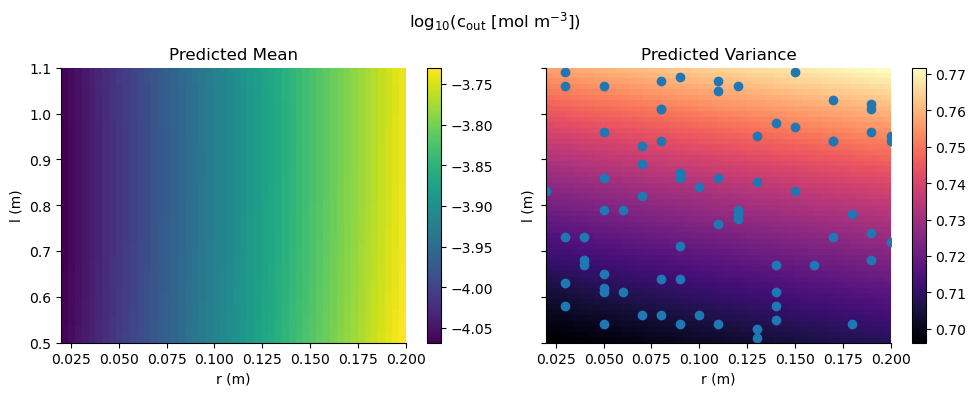

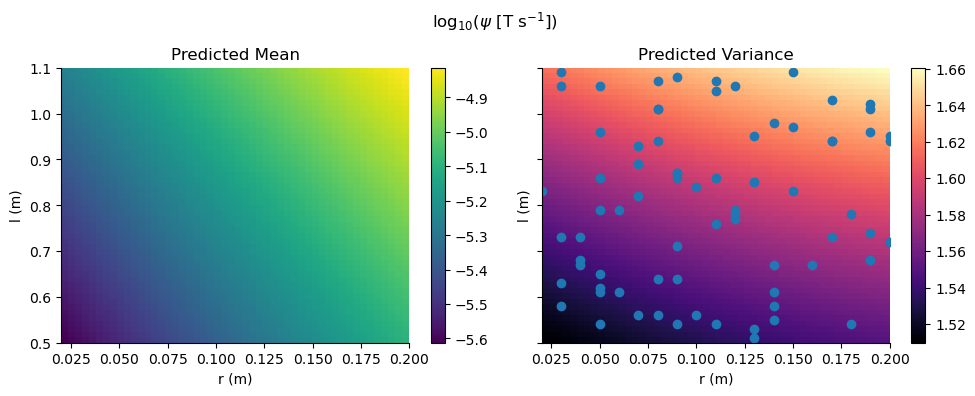

In [175]:
# plot mean and variance fixed slice
from autoemulate.core.plotting import create_and_plot_slice

plot_labels = {
    "bend_radius": r"r (m)",
    "length": r"l (m)",
    "v_in": r"v$_{\mathrm{in}}$ (m s$^{-1}$)",
    "c_in": r"log$_{10}$(c$_{\mathrm{in}}$ [mol m$^{-3}$])",
}

simulator_to_results_array = {"v_in": 1, "c_in": 0, "bend_radius": 2, "length": 3}

if isinstance(simulator.parameters_range, dict):
    param_names = list(simulator.parameters_range.keys())
elif hasattr(simulator.parameters_range, "keys"):
    param_names = list(simulator.parameters_range.keys())
else:
    param_names = [p[0] for p in simulator.parameters_range]


for i in range(2):
    param_pair = (0, 1)
    x_name, y_name = param_names[param_pair[0]], param_names[param_pair[1]]
    X_train_standardized = scaler.transform(X)
    fig, axs = create_and_plot_slice(
        emulator,
        output_idx=i,
        parameters_range=simulator.parameters_range,
        quantile=0.5,
        param_pair=param_pair,
    )
    x_label = plot_labels.get(x_name, x_name)
    y_label = plot_labels.get(y_name, y_name)

    axs[0][0].set_xlabel(x_label)
    axs[0][1].set_xlabel(x_label)
    axs[0][0].set_ylabel(y_label)
    axs[0][1].set_ylabel(y_label)
    axs[0][0].set_title("Predicted Mean")
    axs[0][1].set_title("Predicted Variance")
    axs[0][0].spines["top"].set_visible(False)
    axs[0][1].spines["top"].set_visible(False)
    axs[0][0].spines["right"].set_visible(False)
    axs[0][1].spines["right"].set_visible(False)

    plt.scatter(
        X[:, simulator_to_results_array[x_name]],
        X[:, simulator_to_results_array[y_name]],
    )
    if i == 0:
        plt.suptitle(r"log$_{10}$(c$_{\mathrm{out}}$ [mol m$^{-3}$])")
    else:
        plt.suptitle(r"log$_{10}$($\psi$ [T s$^{-1}$])")

    # plt.savefig("mean-variance.pdf")
    plt.show()

creating mean and variance plots...


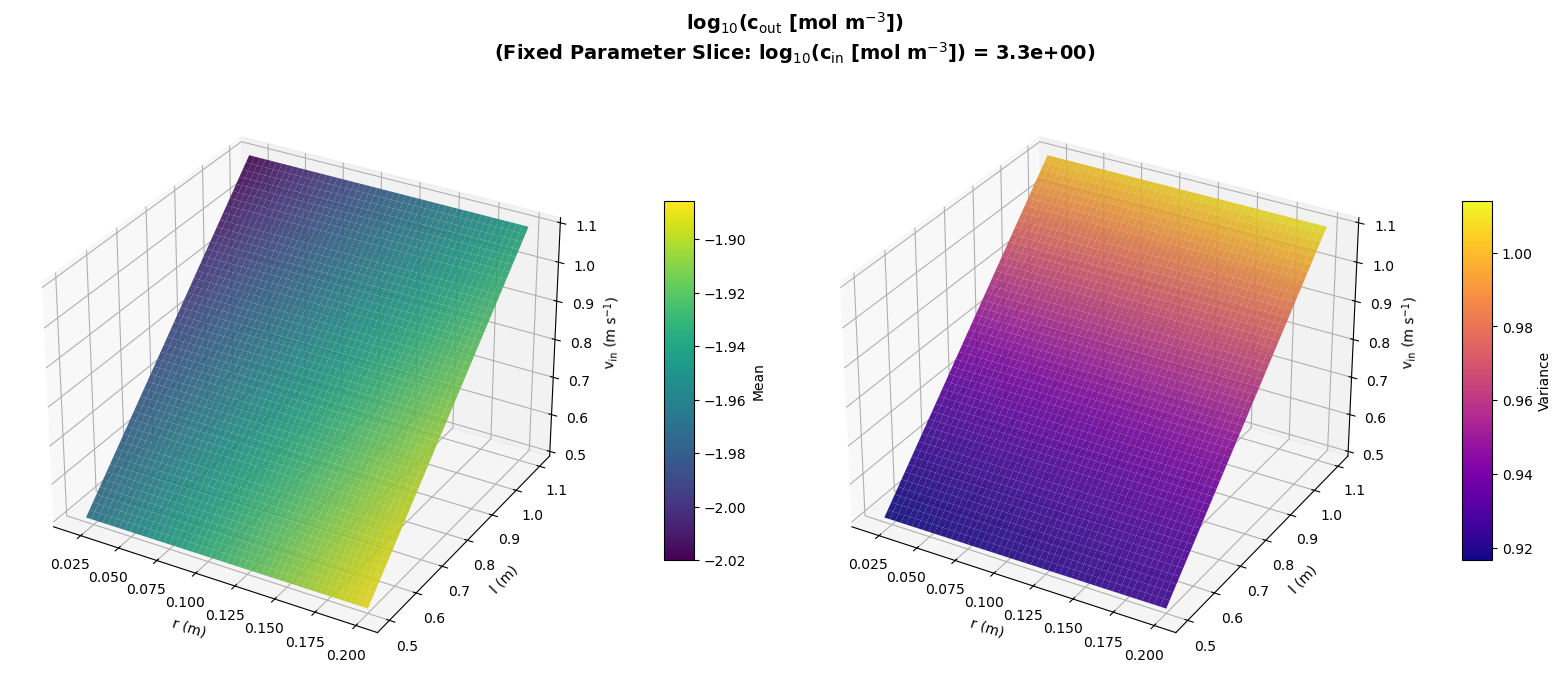

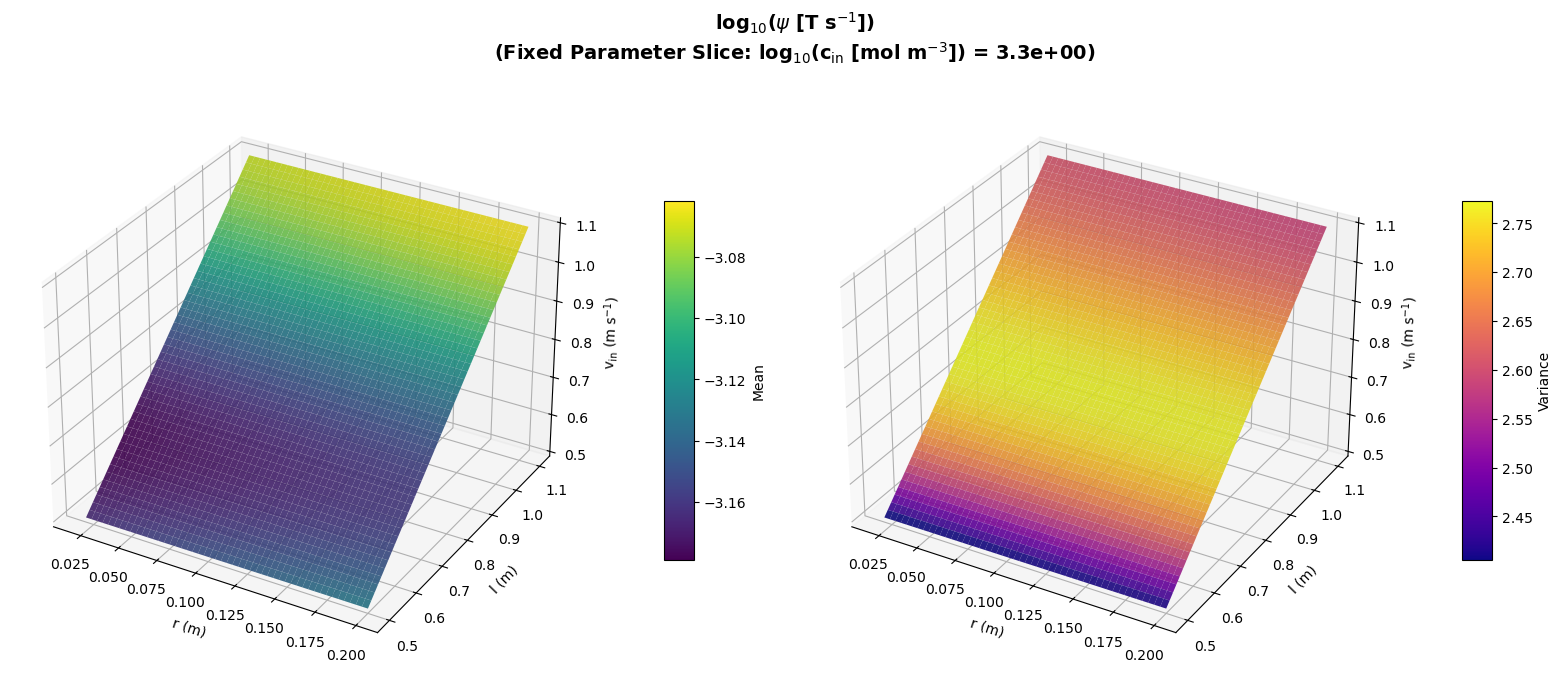

Plotting complete!


In [6]:
## FIXED C_IN 3D MEAN/VARIANCE PLOTS

import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch

print("creating mean and variance plots...")

param_bounds = {
    "bend_radius": (0.02, 0.2),
    "length": (0.5, 1.1),
    "v_in": (min_velocity, 0.97),
    "c_in": (np.log10(1e16 / N_A), np.log10(1e25 / N_A)),
}

active_x = "bend_radius"
active_y = "length"
active_z = "length"

# fixed c_in for these
fixed_params = ["c_in"]
fixed_vals = {
    p: abs((param_bounds[p][0] + param_bounds[p][1]) / 2.0) for p in fixed_params
}


# make 2D mesh grid
grid_res = 50
x_space = np.linspace(param_bounds[active_x][0], param_bounds[active_x][1], grid_res)
y_space = np.linspace(param_bounds[active_y][0], param_bounds[active_y][1], grid_res)
X_grid, Y_grid = np.meshgrid(x_space, y_space)

# z-grid of same shape as x and y
z_space = np.linspace(param_bounds[active_z][0], param_bounds[active_z][1], grid_res)
Z_grid = np.repeat(z_space[:, np.newaxis], grid_res, axis=1)

# make trained data array
total_samples = X_grid.size
X_pred = np.zeros((total_samples, 4))
X_pred[:, 0] = X_grid.flatten()
X_pred[:, 1] = Y_grid.flatten()
X_pred[:, 2] = Z_grid.flatten()
X_pred[:, 3] = fixed_vals["c_in"]

# predict mean and variance needs a torch
X_pred_tensor = torch.from_numpy(X_pred).float()
mean_tensor, var_tensor = emulator.predict_mean_and_variance(X_pred_tensor)

# convert back to numpy
mean_pred = mean_tensor.detach().cpu().numpy()
var_pred = var_tensor.detach().cpu().numpy()

mean_grid_out1 = mean_pred[:, 0].reshape(grid_res, grid_res)
mean_grid_out2 = mean_pred[:, 1].reshape(grid_res, grid_res)
var_grid_out1 = var_pred[:, 0].reshape(grid_res, grid_res)
var_grid_out2 = var_pred[:, 1].reshape(grid_res, grid_res)

outputs_to_render = [
    {
        "title": r"log$_{10}$(c$_{\mathrm{out}}$ [mol m$^{-3}$])",
        "mean": mean_grid_out1,
        "var": var_grid_out1,
    },
    {
        "title": r"log$_{10}$($\psi$ [T s$^{-1}$])",
        "mean": mean_grid_out2,
        "var": var_grid_out2,
    },
]

# plotting
for out in outputs_to_render:
    fig = plt.figure(figsize=(16, 7))

    # mean plot
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")

    norm_mean = (out["mean"] - np.min(out["mean"])) / (
        np.max(out["mean"]) - np.min(out["mean"]) + 1e-12
    )
    surf1 = ax1.plot_surface(
        X_grid,
        Y_grid,
        Z_grid,
        facecolors=cm.viridis(norm_mean),
        linewidth=0,
        antialiased=True,
        alpha=0.9,
    )
    ax1.set_xlabel(r"r (m)", fontsize=10)
    ax1.set_ylabel(r"l (m)", fontsize=10)
    ax1.set_zlabel(r"v$_{\mathrm{in}}$ (m s$^{-1}$)", fontsize=10)

    m1 = cm.ScalarMappable(cmap=cm.viridis)
    m1.set_array(out["mean"])
    fig.colorbar(m1, ax=ax1, shrink=0.6, aspect=12, pad=0.1, label="Mean")

    # variance plot
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")

    norm_var = (out["var"] - np.min(out["var"])) / (
        np.max(out["var"]) - np.min(out["var"]) + 1e-12
    )
    surf2 = ax2.plot_surface(
        X_grid,
        Y_grid,
        Z_grid,
        facecolors=cm.plasma(norm_var),
        linewidth=0,
        antialiased=True,
        alpha=0.9,
    )
    ax2.set_xlabel(r"r (m)", fontsize=10)
    ax2.set_ylabel(r"l (m)", fontsize=10)
    ax2.set_zlabel(r"v$_{\mathrm{in}}$ (m s$^{-1}$)", fontsize=10)

    m2 = cm.ScalarMappable(cmap=cm.plasma)
    m2.set_array(out["var"])
    fig.colorbar(m2, ax=ax2, shrink=0.6, aspect=12, pad=0.1, label="Variance")

    subtitle_details = (
        r"Fixed Parameter Slice: log$_{10}$(c$_{\mathrm{in}}$ [mol m$^{-3}$]) ="
        + f" {fixed_vals['c_in']:.1e}"
    )
    fig.suptitle(
        f"{out['title']}\n({subtitle_details})", fontsize=14, weight="bold", y=0.98
    )

    plt.tight_layout()
    plt.show()

print("Plotting complete!")

creating mean and variance plots...


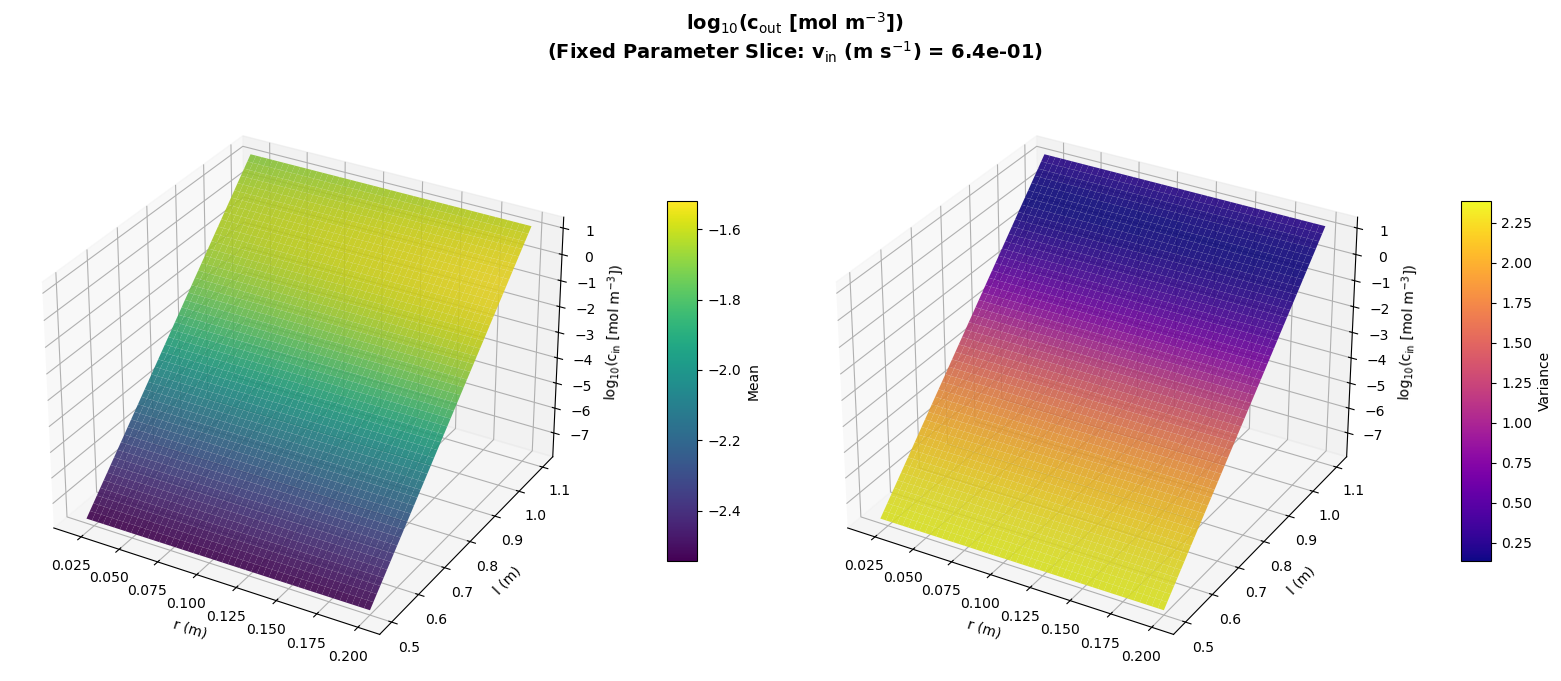

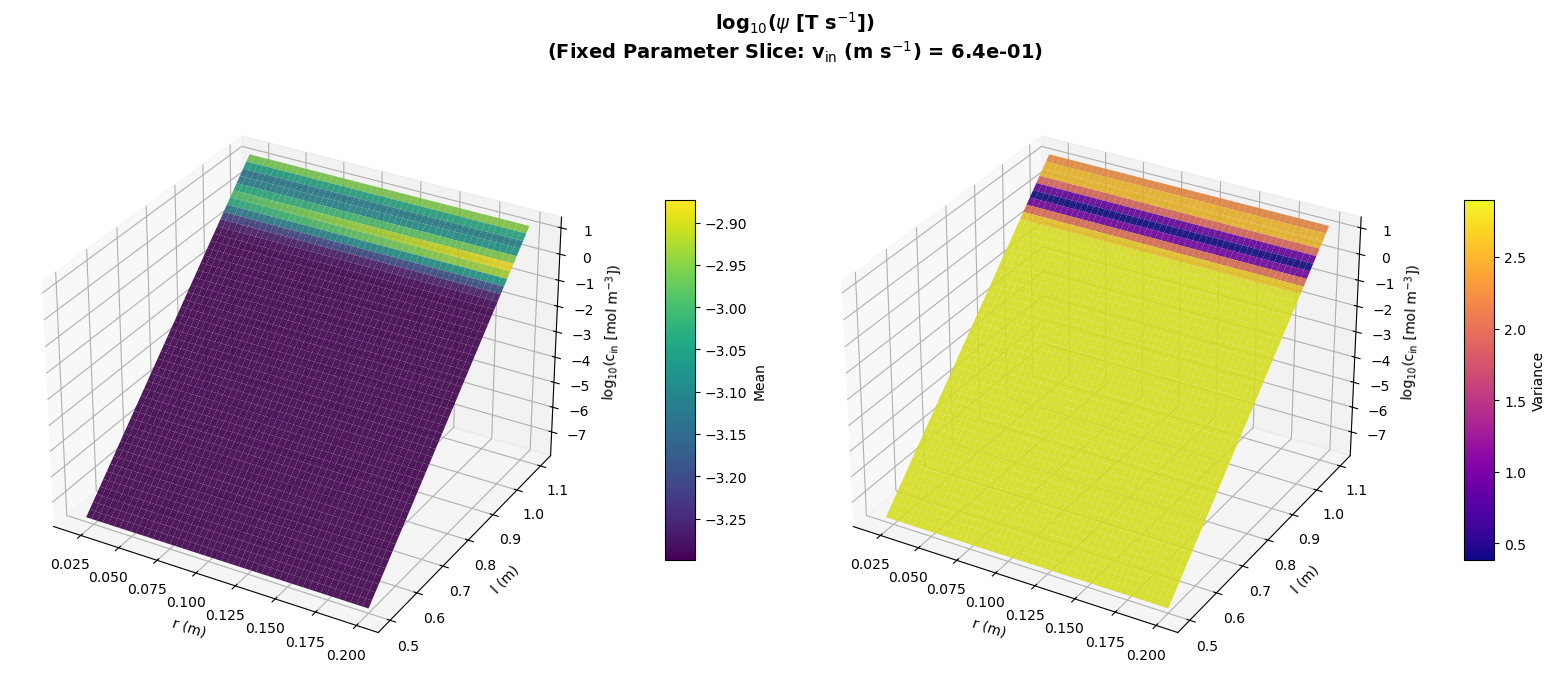

Plotting complete!


In [7]:
## FIXED v_in 3D MEAN/VARIANCE PLOTS

import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch

print("creating mean and variance plots...")

param_bounds = {
    "bend_radius": (0.02, 0.2),
    "length": (0.5, 1.1),
    "v_in": (min_velocity, 0.97),
    "c_in": (np.log10(1e16 / N_A), np.log10(1e25 / N_A)),
}

active_x = "bend_radius"
active_y = "length"
active_z = "c_in"

# fixed v_in for these
fixed_params = ["v_in"]
fixed_vals = {
    p: abs((param_bounds[p][0] + param_bounds[p][1]) / 2.0) for p in fixed_params
}


# make 2D mesh grid
grid_res = 50
x_space = np.linspace(param_bounds[active_x][0], param_bounds[active_x][1], grid_res)
y_space = np.linspace(param_bounds[active_y][0], param_bounds[active_y][1], grid_res)
X_grid, Y_grid = np.meshgrid(x_space, y_space)

# z-grid of same shape as x and y
z_space = np.linspace(param_bounds[active_z][0], param_bounds[active_z][1], grid_res)
Z_grid = np.repeat(z_space[:, np.newaxis], grid_res, axis=1)

# make trained data array
total_samples = X_grid.size
X_pred = np.zeros((total_samples, 4))
X_pred[:, 0] = X_grid.flatten()
X_pred[:, 1] = Y_grid.flatten()
X_pred[:, 2] = Z_grid.flatten()
X_pred[:, 3] = fixed_vals["v_in"]

# predict mean and variance needs a torch
X_pred_tensor = torch.from_numpy(X_pred).float()
mean_tensor, var_tensor = emulator.predict_mean_and_variance(X_pred_tensor)

# convert back to numpy
mean_pred = mean_tensor.detach().cpu().numpy()
var_pred = var_tensor.detach().cpu().numpy()

mean_grid_out1 = mean_pred[:, 0].reshape(grid_res, grid_res)
mean_grid_out2 = mean_pred[:, 1].reshape(grid_res, grid_res)
var_grid_out1 = var_pred[:, 0].reshape(grid_res, grid_res)
var_grid_out2 = var_pred[:, 1].reshape(grid_res, grid_res)

outputs_to_render = [
    {
        "title": r"log$_{10}$(c$_{\mathrm{out}}$ [mol m$^{-3}$])",
        "mean": mean_grid_out1,
        "var": var_grid_out1,
    },
    {
        "title": r"log$_{10}$($\psi$ [T s$^{-1}$])",
        "mean": mean_grid_out2,
        "var": var_grid_out2,
    },
]

# plotting
for out in outputs_to_render:
    fig = plt.figure(figsize=(16, 7))

    # mean plot
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")

    norm_mean = (out["mean"] - np.min(out["mean"])) / (
        np.max(out["mean"]) - np.min(out["mean"]) + 1e-12
    )
    surf1 = ax1.plot_surface(
        X_grid,
        Y_grid,
        Z_grid,
        facecolors=cm.viridis(norm_mean),
        linewidth=0,
        antialiased=True,
        alpha=0.9,
    )
    ax1.set_xlabel(r"r (m)", fontsize=10)
    ax1.set_ylabel(r"l (m)", fontsize=10)
    ax1.set_zlabel(r"log$_{10}$(c$_{\mathrm{in}}$ [mol m$^{-3}$])", fontsize=10)

    m1 = cm.ScalarMappable(cmap=cm.viridis)
    m1.set_array(out["mean"])
    fig.colorbar(m1, ax=ax1, shrink=0.6, aspect=12, pad=0.1, label="Mean")

    # variance plot
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")

    norm_var = (out["var"] - np.min(out["var"])) / (
        np.max(out["var"]) - np.min(out["var"]) + 1e-12
    )
    surf2 = ax2.plot_surface(
        X_grid,
        Y_grid,
        Z_grid,
        facecolors=cm.plasma(norm_var),
        linewidth=0,
        antialiased=True,
        alpha=0.9,
    )
    ax2.set_xlabel(r"r (m)", fontsize=10)
    ax2.set_ylabel(r"l (m)", fontsize=10)
    ax2.set_zlabel(r"log$_{10}$(c$_{\mathrm{in}}$ [mol m$^{-3}$])", fontsize=10)

    m2 = cm.ScalarMappable(cmap=cm.plasma)
    m2.set_array(out["var"])
    fig.colorbar(m2, ax=ax2, shrink=0.6, aspect=12, pad=0.1, label="Variance")

    subtitle_details = (
        r"Fixed Parameter Slice: v$_{\mathrm{in}}$ (m s$^{-1}$) ="
        + f" {fixed_vals['v_in']:.1e}"
    )
    fig.suptitle(
        f"{out['title']}\n({subtitle_details})", fontsize=14, weight="bold", y=0.98
    )

    plt.tight_layout()
    plt.show()

print("Plotting complete!")

creating mean and variance plots...


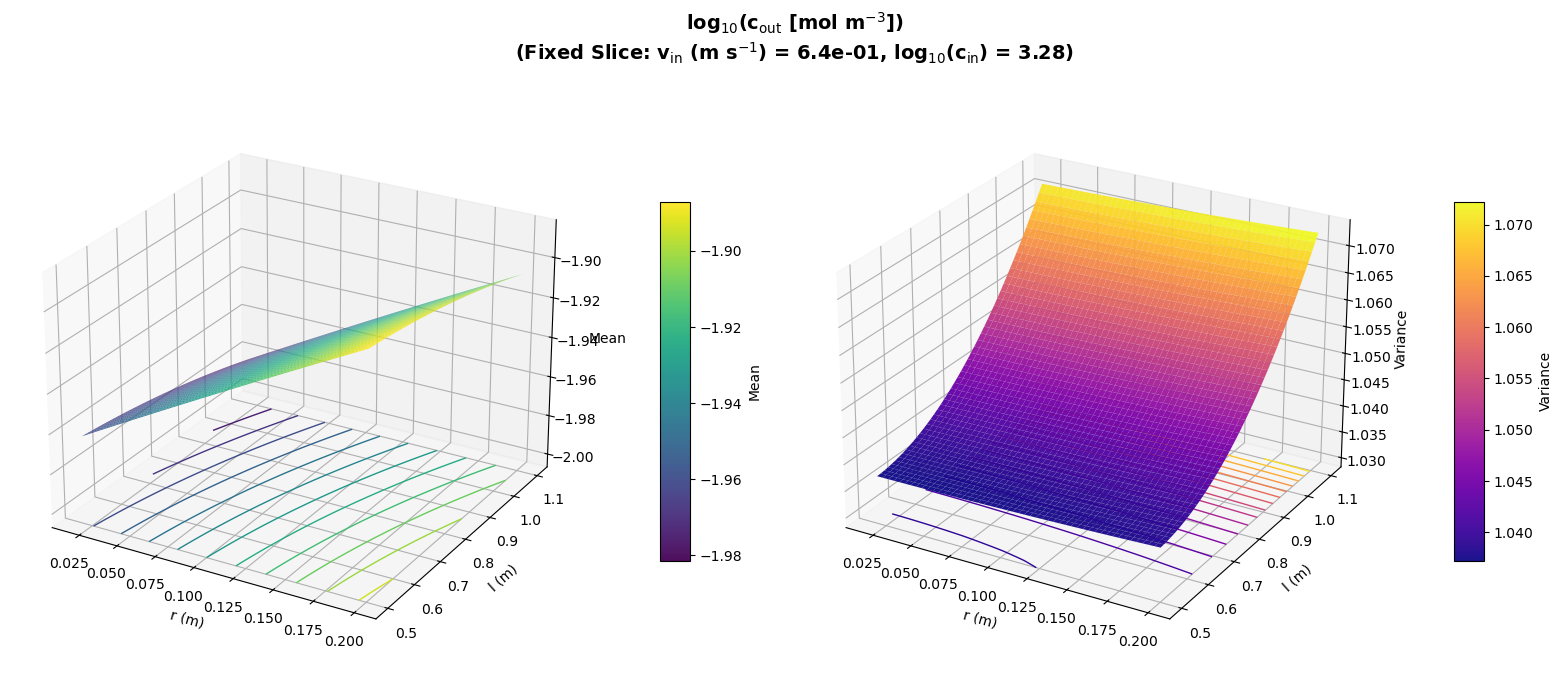

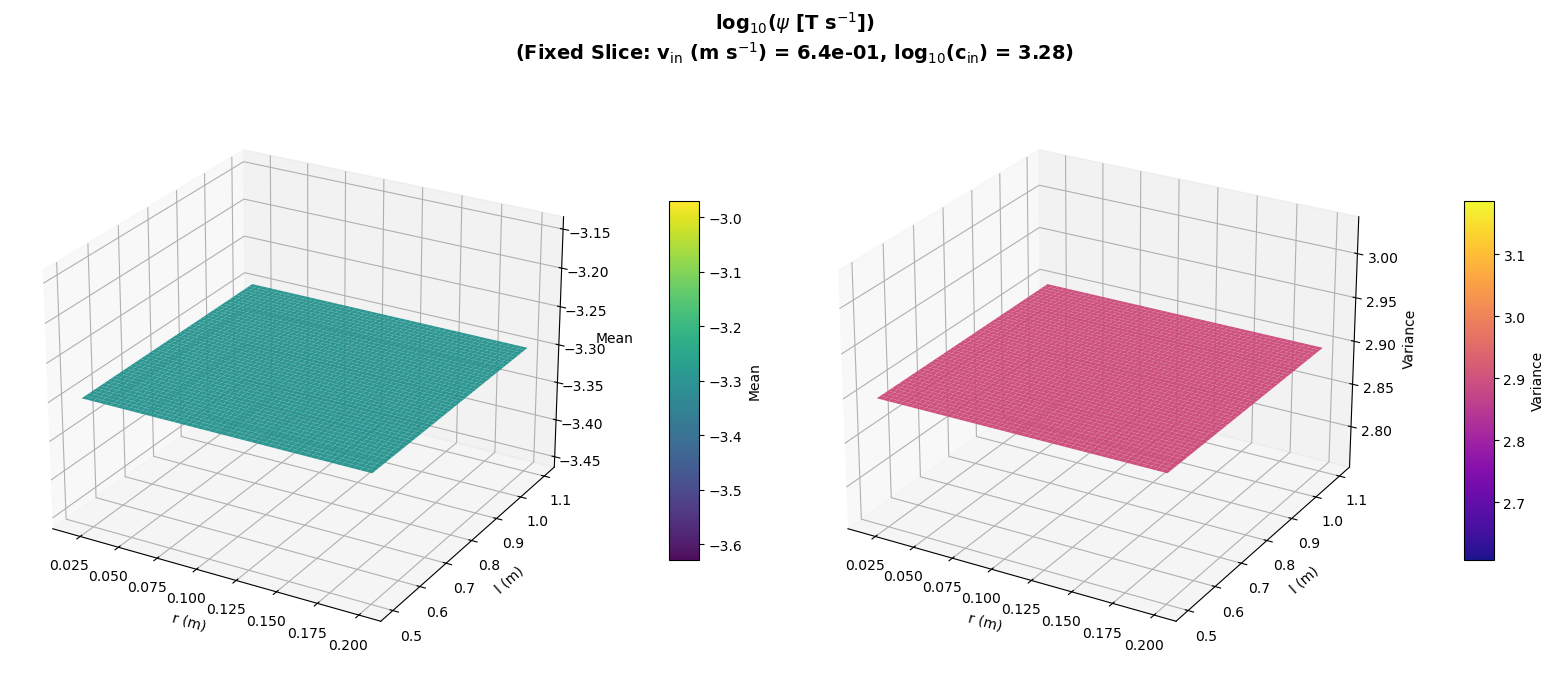

Plotting complete!


In [8]:
## FIXED v_in & c_in -> TRUE 3D SURFACE MEAN/VARIANCE PLOTS

import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch

print("creating mean and variance plots...")

param_bounds = {
    "bend_radius": (0.02, 0.2),
    "length": (0.5, 1.1),
    "v_in": (min_velocity, 0.97),
    "c_in": (np.log10(1e16 / N_A), np.log10(1e25 / N_A)),
}

active_x = "bend_radius"
active_y = "length"

fixed_params = ["v_in", "c_in"]
fixed_vals = {
    p: abs((param_bounds[p][0] + param_bounds[p][1]) / 2.0) for p in fixed_params
}

# make 2D mesh grid over the two free inputs only
grid_res = 50
x_space = np.linspace(param_bounds[active_x][0], param_bounds[active_x][1], grid_res)
y_space = np.linspace(param_bounds[active_y][0], param_bounds[active_y][1], grid_res)
X_grid, Y_grid = np.meshgrid(x_space, y_space)

# build prediction input array
total_samples = X_grid.size
X_pred = np.zeros((total_samples, 4))
X_pred[:, 0] = X_grid.flatten()
X_pred[:, 1] = Y_grid.flatten()
X_pred[:, 2] = fixed_vals["c_in"]
X_pred[:, 3] = fixed_vals["v_in"]

# predict mean and variance
X_pred_tensor = torch.from_numpy(X_pred).float()
mean_tensor, var_tensor = emulator.predict_mean_and_variance(X_pred_tensor)

mean_pred = mean_tensor.detach().cpu().numpy()
var_pred = var_tensor.detach().cpu().numpy()

mean_grid_out1 = mean_pred[:, 0].reshape(grid_res, grid_res)
mean_grid_out2 = mean_pred[:, 1].reshape(grid_res, grid_res)
var_grid_out1 = var_pred[:, 0].reshape(grid_res, grid_res)
var_grid_out2 = var_pred[:, 1].reshape(grid_res, grid_res)

outputs_to_render = [
    {
        "title": r"log$_{10}$(c$_{\mathrm{out}}$ [mol m$^{-3}$])",
        "mean": mean_grid_out1,
        "var": var_grid_out1,
    },
    {
        "title": r"log$_{10}$($\psi$ [T s$^{-1}$])",
        "mean": mean_grid_out2,
        "var": var_grid_out2,
    },
]


def plot_surface_with_floor_contour(ax, X, Y, Z, cmap, zlabel):
    """Plot a real 3D surface (height = Z) with a contour projection on the floor."""
    surf = ax.plot_surface(
        X,
        Y,
        Z,
        cmap=cmap,
        linewidth=0,
        antialiased=True,
        alpha=0.95,
        rstride=1,
        cstride=1,
    )

    z_range = np.max(Z) - np.min(Z) + 1e-12
    floor = np.min(Z) - 0.25 * z_range  # push floor below surface for contour room
    ax.contour(X, Y, Z, zdir="z", offset=floor, cmap=cmap, linewidths=1.0, levels=15)
    ax.set_zlim(floor, np.max(Z) + 0.05 * z_range)

    ax.set_xlabel(r"r (m)", fontsize=10)
    ax.set_ylabel(r"l (m)", fontsize=10)
    ax.set_zlabel(zlabel, fontsize=10)
    ax.view_init(elev=25, azim=-60)  # similar viewing angle to the reference plot
    return surf


for out in outputs_to_render:
    fig = plt.figure(figsize=(16, 7))

    # mean plot
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    surf1 = plot_surface_with_floor_contour(
        ax1, X_grid, Y_grid, out["mean"], cm.viridis, "Mean"
    )
    fig.colorbar(surf1, ax=ax1, shrink=0.6, aspect=12, pad=0.1, label="Mean")

    # variance plot
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    surf2 = plot_surface_with_floor_contour(
        ax2, X_grid, Y_grid, out["var"], cm.plasma, "Variance"
    )
    fig.colorbar(surf2, ax=ax2, shrink=0.6, aspect=12, pad=0.1, label="Variance")

    subtitle_details = (
        r"Fixed Slice: v$_{\mathrm{in}}$ (m s$^{-1}$) = "
        + f"{fixed_vals['v_in']:.1e}, "
        + r"log$_{10}$(c$_{\mathrm{in}}$) = "
        + f"{fixed_vals['c_in']:.2f}"
    )
    fig.suptitle(
        f"{out['title']}\n({subtitle_details})", fontsize=14, weight="bold", y=0.98
    )

    plt.tight_layout()
    plt.show()

print("Plotting complete!")

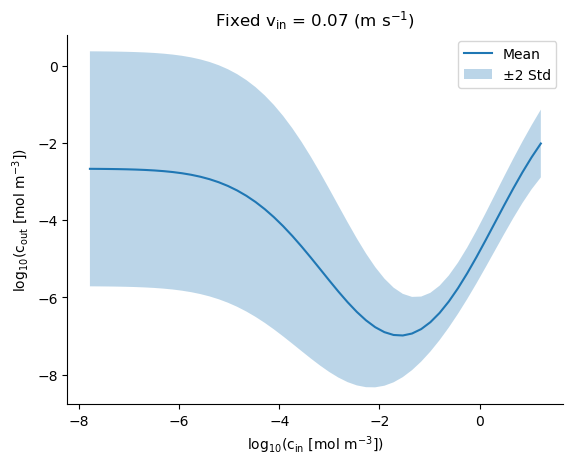

In [176]:
# plot 1d slice for fixed v_in, l, and r

n_points = 50
c_in_range = simulator.parameters_range["c_in"]

fixed_params = ["v_in", "bend_radius", "length"]
fixed_vals = {
    p: abs((param_bounds[p][0] + param_bounds[p][1]) / 2.0) for p in fixed_params
}

c_in_vals = np.linspace(c_in_range[0], c_in_range[1], n_points)
c_in = np.column_stack(
    [
        c_in_vals,
        np.full(n_points, fixed_vals["v_in"]),
        np.full(n_points, fixed_vals["bend_radius"]),
        np.full(n_points, fixed_vals["length"]),
    ]
)
c_in = torch.from_numpy(c_in).float()


y_mean, y_var = emulator.predict_mean_and_variance(c_in)
y_mean = np.array(y_mean)
y_var = np.array(y_var).flatten()

fig, ax = plt.subplots()

# plotting values
y_mean_1d = y_mean[:, 0]  # c_out values
y_std_1d = np.sqrt(y_var[::2])

# actual plotting
ax.plot(c_in_vals, y_mean_1d, label="Mean")
ax.fill_between(
    c_in_vals,
    y_mean_1d - 2 * y_std_1d,
    y_mean_1d + 2 * y_std_1d,
    alpha=0.3,
    label="±2 Std",
)
ax.set_ylabel(r"log$_{10}$(c$_{\mathrm{out}}$ [mol m$^{-3}$])")
ax.set_xlabel(r"log$_{10}$(c$_{\mathrm{in}}$ [mol m$^{-3}$])")
ax.set_title(r"Fixed v$_{\mathrm{in}}$ = 0.07 (m s$^{-1}$)")
# ax.set_ylim(-10, 5)
ax.tick_params(labeltop=False, labelbottom=True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# plt.savefig("vin-fixed.pdf")
ax.legend()
plt.show()

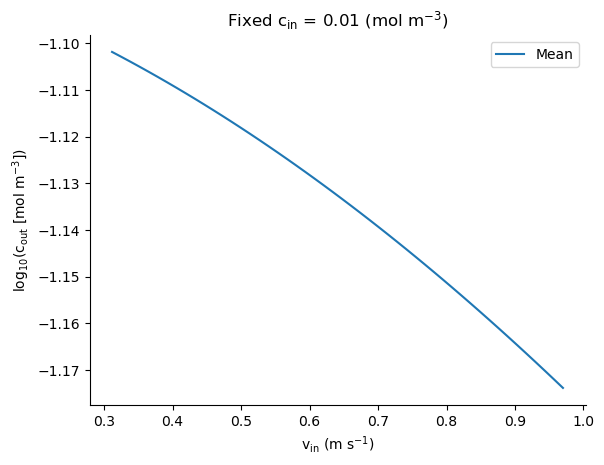

In [167]:
# plot 1d slice for fixed c_in, l, and r

n_points = 50
v_in_range = simulator.parameters_range["v_in"]

fixed_params = ["c_in", "bend_radius", "length"]
fixed_vals = {
    p: abs((param_bounds[p][0] + param_bounds[p][1]) / 2.0) for p in fixed_params
}

v_in_vals = np.linspace(v_in_range[0], v_in_range[1], n_points)
v_in = np.column_stack(
    [
        np.full(n_points, fixed_vals["c_in"]),
        v_in_vals,
        np.full(n_points, fixed_vals["bend_radius"]),
        np.full(n_points, fixed_vals["length"]),
    ]
)
v_in = torch.from_numpy(v_in).float()


y_mean, y_var = emulator.predict_mean_and_variance(v_in)
y_mean = np.array(y_mean)
y_var = np.array(y_var).flatten()

fig, ax = plt.subplots()

# plotting values
y_mean_1d = y_mean[:, 0]  # c_out values
y_std_1d = np.sqrt(y_var[::2])

# actual plotting
ax.plot(v_in_vals, y_mean_1d, label="Mean")
# ax.fill_between(v_in_vals,
#                 y_mean_1d - 2*y_std_1d,
#                 y_mean_1d + 2*y_std_1d,
#                 alpha=0.3, label='±2 Std')
ax.set_xlabel(r"v$_{\mathrm{in}}$ (m s$^{-1}$)")
ax.set_ylabel(r"log$_{10}$(c$_{\mathrm{out}}$ [mol m$^{-3}$])")
ax.set_title(r"Fixed c$_{\mathrm{in}}$ = 0.01 (mol m$^{-3}$)")
# ax.set_ylim(-10, 2)
ax.tick_params(labeltop=False, labelbottom=True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# plt.savefig("cin-fixed.pdf")
ax.legend()
plt.show()

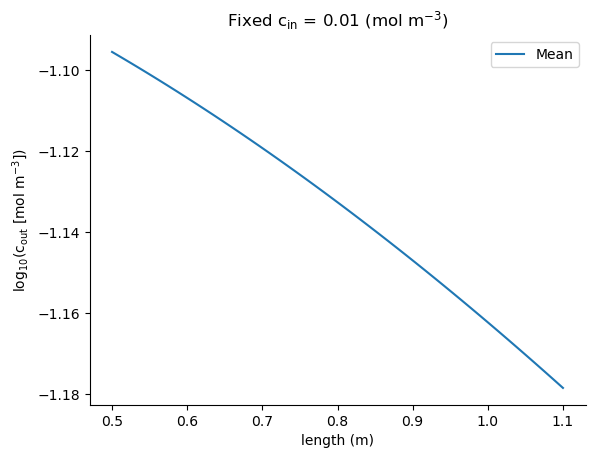

In [165]:
# plot 1d slice for fixed c_in, v_in, and r

n_points = 50
length_range = simulator.parameters_range["length"]

fixed_params = ["c_in", "bend_radius", "v_in"]
fixed_vals = {
    p: abs((param_bounds[p][0] + param_bounds[p][1]) / 2.0) for p in fixed_params
}

length_vals = np.linspace(length_range[0], length_range[1], n_points)
length = np.column_stack(
    [
        np.full(n_points, fixed_vals["c_in"]),
        np.full(n_points, fixed_vals["v_in"]),
        np.full(n_points, fixed_vals["bend_radius"]),
        length_vals,
    ]
)
length = torch.from_numpy(length).float()


y_mean, y_var = emulator.predict_mean_and_variance(length)
y_mean = np.array(y_mean)
y_var = np.array(y_var).flatten()

fig, ax = plt.subplots()

# plotting values
y_mean_1d = y_mean[:, 0]  # c_out values
y_std_1d = np.sqrt(y_var[::2])

# actual plotting
ax.plot(length_vals, y_mean_1d, label="Mean")
# ax.fill_between(length_vals,
#                 y_mean_1d - 2*y_std_1d,
#                 y_mean_1d + 2*y_std_1d,
#                 alpha=0.3, label='±2 Std')
ax.set_xlabel(r"length (m)")
ax.set_ylabel(r"log$_{10}$(c$_{\mathrm{out}}$ [mol m$^{-3}$])")
ax.set_title(r"Fixed c$_{\mathrm{in}}$ = 0.01 (mol m$^{-3}$)")
# ax.set_ylim(-0.5, 0.5)
ax.tick_params(labeltop=False, labelbottom=True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# plt.savefig("length-fixed.pdf")
ax.legend()
plt.show()

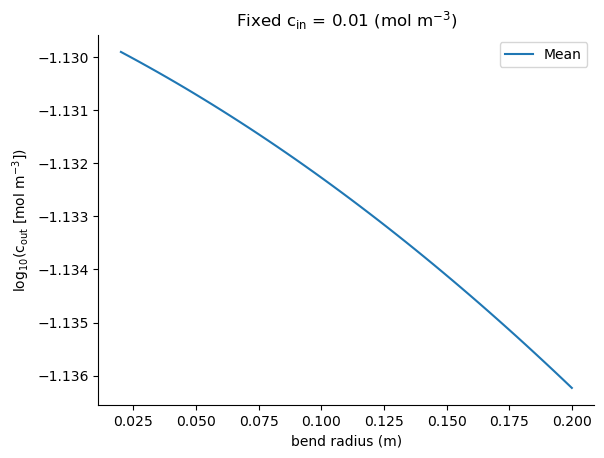

In [163]:
# plot 1d slice for fixed c_in, v_in, and length

n_points = 50
bend_radius_range = simulator.parameters_range["bend_radius"]

fixed_params = ["c_in", "length", "v_in"]
fixed_vals = {
    p: abs((param_bounds[p][0] + param_bounds[p][1]) / 2.0) for p in fixed_params
}

bend_radius_vals = np.linspace(bend_radius_range[0], bend_radius_range[1], n_points)
bend_radius = np.column_stack(
    [
        np.full(n_points, fixed_vals["c_in"]),
        np.full(n_points, fixed_vals["v_in"]),
        bend_radius_vals,
        np.full(n_points, fixed_vals["length"]),
    ]
)
bend_radius = torch.from_numpy(bend_radius).float()


y_mean, y_var = emulator.predict_mean_and_variance(bend_radius)
y_mean = np.array(y_mean)
y_var = np.array(y_var).flatten()

fig, ax = plt.subplots()

# plotting values
y_mean_1d = y_mean[:, 0]  # c_out values
y_std_1d = np.sqrt(y_var[::2])

# actual plotting
ax.plot(bend_radius_vals, y_mean_1d, label="Mean")
# ax.fill_between(bend_radius_vals,
#                 y_mean_1d - 2*y_std_1d,
#                 y_mean_1d + 2*y_std_1d,
#                 alpha=0.3, label='±2 Std')
ax.set_xlabel(r"bend radius (m)")
ax.set_ylabel(r"log$_{10}$(c$_{\mathrm{out}}$ [mol m$^{-3}$])")
ax.set_title(r"Fixed c$_{\mathrm{in}}$ = 0.01 (mol m$^{-3}$)")
# ax.set_ylim(-0.5, 0.5)
ax.tick_params(labeltop=False, labelbottom=True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# plt.savefig("bend_radius-fixed.pdf")
ax.legend()
plt.show()